# =============================================================================
# Jupyter Notebook about cluster methodology
# Aplication to Weather Regimes
# =============================================================================


## Tomamos los datos del ERA5 en MAM diariamente ( años multiplicados por 92 días)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import cluster

from werim import (
    Dataset, Region, Month,
    Clim, Anom, 
    Preprocess,
    PrincipalComponents,
    WeatherRegimes,
)

In [2]:
DATASETS_DIR = "/Users/Shared/datasets"

ds = Dataset("slp_daily_1940_2024_era5data1g.nc", folder=DATASETS_DIR).open()
ds.slice(Region(
    lat0=20, latf=64, lon0=-40, lonf=39,
    month0=Month.MAR, monthf=Month.MAY,
    year0=1940, yearf=2024,
))

INFO 2026-06-30 19:26:33: Detected variable msl from: msl


((<Figure size 800x600 with 2 Axes>,), ((<GeoAxes: >,),))

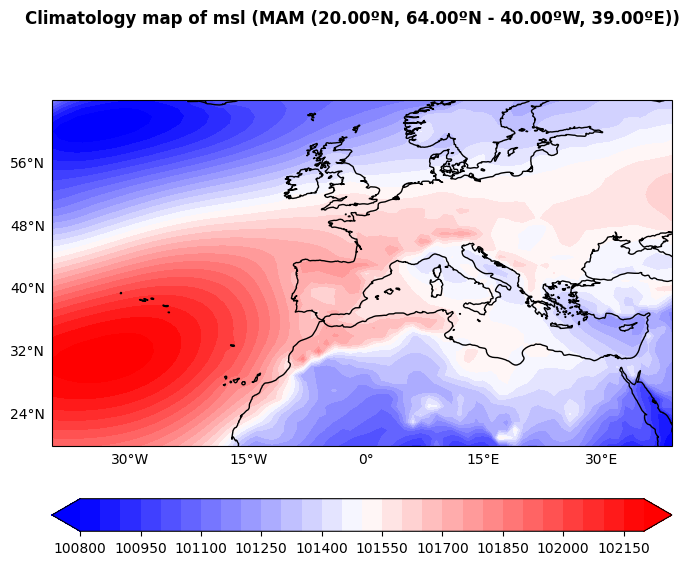

In [3]:
Clim(ds, "map").plot(cmap="bwr", levels=30, figsize=(8, 6))

((<Figure size 800x600 with 2 Axes>,), ((<GeoAxes: >,),))

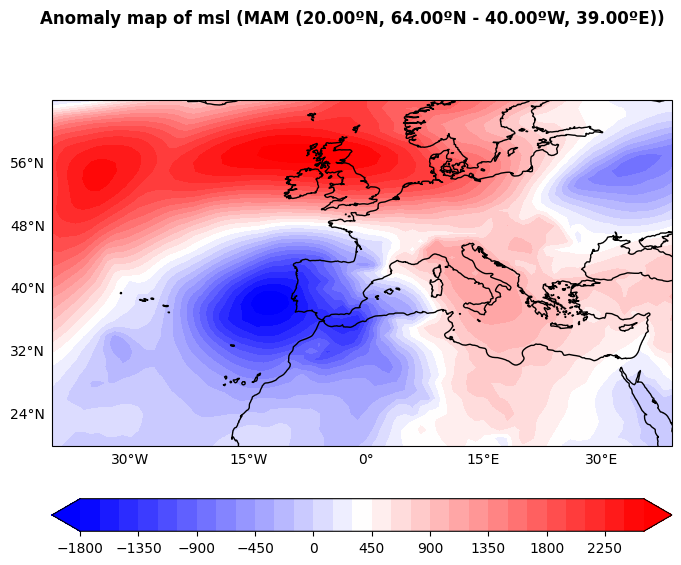

In [4]:
anom = Anom(ds, "map", group_season=False)
anom.plot(timestamp="1940-03-01", cmap="bwr", levels=30, figsize=(8, 6))

Finally, we reshape for having all times together

In [5]:
anom.data.shape #años,dias, lat,lon

(7820, 45, 80)

=============================================================================
# ANALISIS EOF
# =============================================================================
 Ahora vamos a calcular los principales modos de variabilidad del z600 anómalo. Para ello, primero eliminamos la tendencia y aplicamos la función EOF, definida anteriormente. La función tiene que ser aplicada a datos con dimensiones (ns, nt), así que transponemos, y reformamos para tener 2 dimensiones# 

In [6]:
nm = 10
alpha = 0.1

In [7]:
pre = Preprocess(ds, detrend=True, group_season=False)
# pre.save("pre_", DATA_DIR)
# pre = Preprocess.load("pre_", DATA_DIR)

INFO 2026-06-30 19:26:33: Preprocessing data for variable msl  took: 0.747 seconds 



((<Figure size 800x600 with 2 Axes>,),
 ((<GeoAxes: title={'center': 'Date: 1940-03-01T00:00:00.000000000'}>,),))

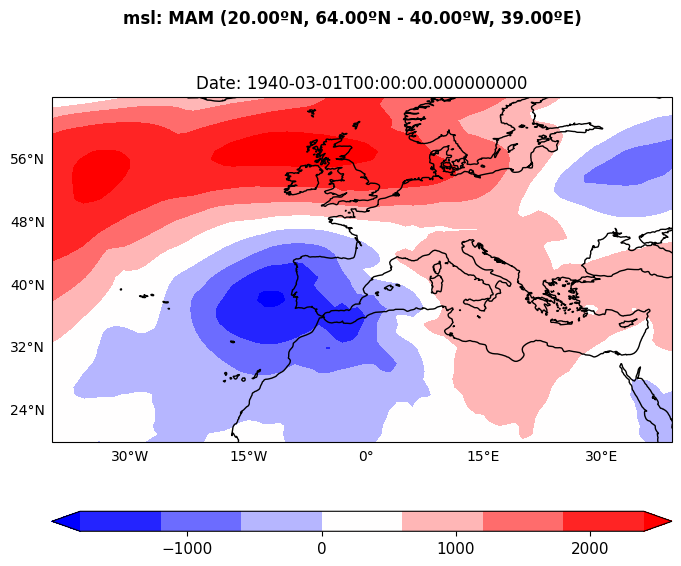

In [8]:
pre.plot(timestamp="1940-03-01", figsize=(8, 6))

In [9]:
pc = PrincipalComponents(pre, nm=nm, alpha=alpha)
# pc.save("pc_", "data")
# pc = PrincipalComponents.load("wr_", "data", ds=pre)

INFO 2026-06-30 19:26:34: Calculating Principal Components and EOFs
    Shape:  (3600, 7820) 
    Region: MAM (20.00ºN, 64.00ºN - 40.00ºW, 39.00ºE)
     Took: 8.357 seconds


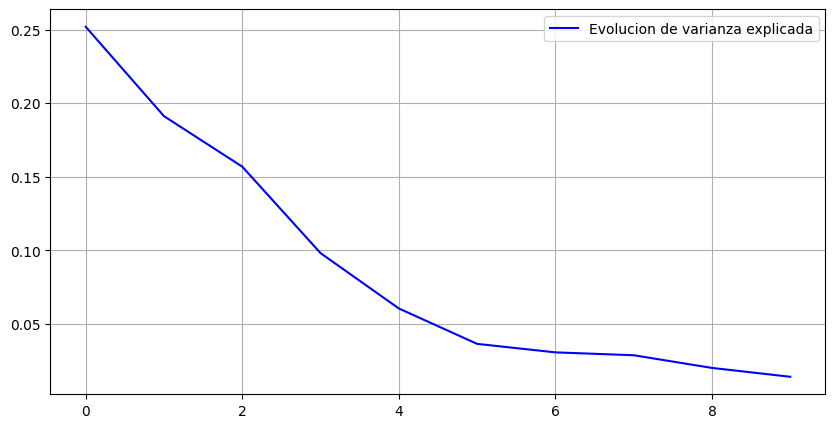

In [10]:
fig, ax = plt.subplots(figsize = (10,5))
plt.plot(pc.fvar[:10], color='Blue', label='Evolucion de varianza explicada')
plt.legend()
plt.grid()

((<Figure size 1700x710.127 with 11 Axes>,),
 ((<GeoAxes: title={'center': 'msl mode 1. fvar=25.2%'}>,
   <GeoAxes: title={'center': 'msl mode 2. fvar=19.1%'}>,
   <GeoAxes: title={'center': 'msl mode 3. fvar=15.7%'}>,
   <GeoAxes: title={'center': 'msl mode 4. fvar=9.8%'}>,
   <GeoAxes: title={'center': 'msl mode 5. fvar=6.1%'}>,
   <GeoAxes: title={'center': 'msl mode 6. fvar=3.7%'}>,
   <GeoAxes: title={'center': 'msl mode 7. fvar=3.1%'}>,
   <GeoAxes: title={'center': 'msl mode 8. fvar=2.9%'}>,
   <GeoAxes: title={'center': 'msl mode 9. fvar=2.0%'}>,
   <GeoAxes: title={'center': 'msl mode 10. fvar=1.4%'}>),))

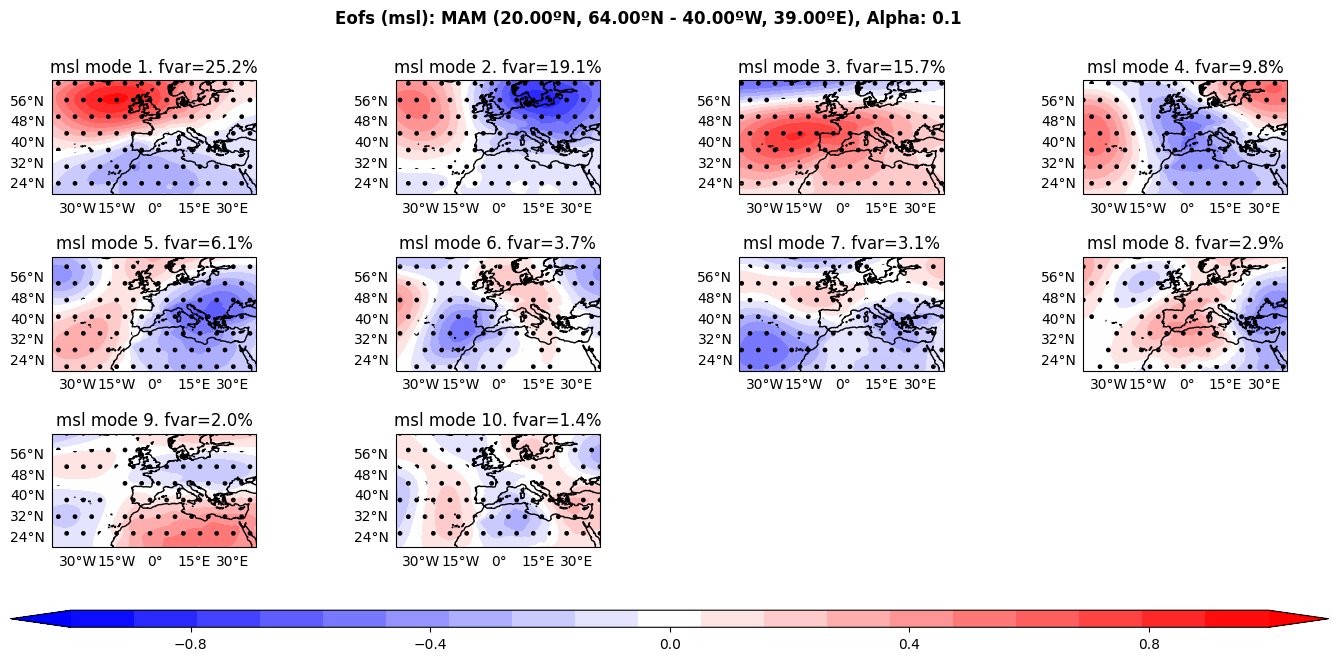

In [11]:
pc.plot()

((<Figure size 1436.36x800 with 4 Axes>,),
 ((<Axes: title={'center': 'msl mode 1. fvar=25.2%'}, xlabel='time'>,
   <Axes: title={'center': 'msl mode 2. fvar=19.1%'}, xlabel='time'>,
   <Axes: title={'center': 'msl mode 3. fvar=15.7%'}, xlabel='time'>,
   <Axes: title={'center': 'msl mode 4. fvar=9.8%'}, xlabel='time'>),))

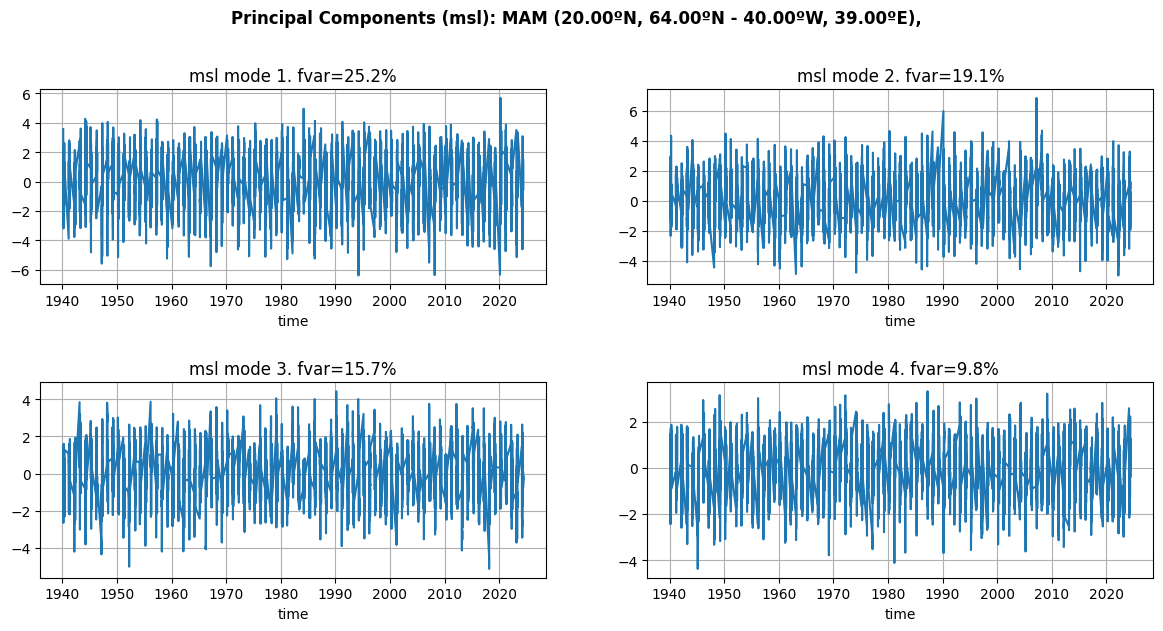

In [12]:
pc.plot_PCs(nm=4)

# =============================================================================
# WEATHER REGIMES (REGÍMENES DE TIEMPO)



### Para calcular los regímenes meteorológicos necesitamos una serie temporal de referencia para ver cuántos regímenes meteorológicos necesitamos para tener uno que explique la variable de impacto hay que ver cuántos WR se necesitan para explicar la serie temporal


### Elijo un número máximo de cluster, por ejemplo, 10 y un umbral de temperatura o un percentil( por ejemplo, p95). 
### La idea es ver cuantos clusters necesito para explicar ese extremo . 
### Además, elijo un número de iteraciones para repetir el proceso y ver si es robusto. 



# Aqui tenéis que adaptar para que, de vuestro índice, tome un umbral y asi selecciones cuántos clusters hacen falta para poder diferenciar un cluster que lo contenga

INFO 2026-06-30 19:26:44: Detected variable pr from: pr


((<Figure size 800x500 with 1 Axes>,),
 ((<Axes: xlabel='Time', ylabel='pr'>,),))

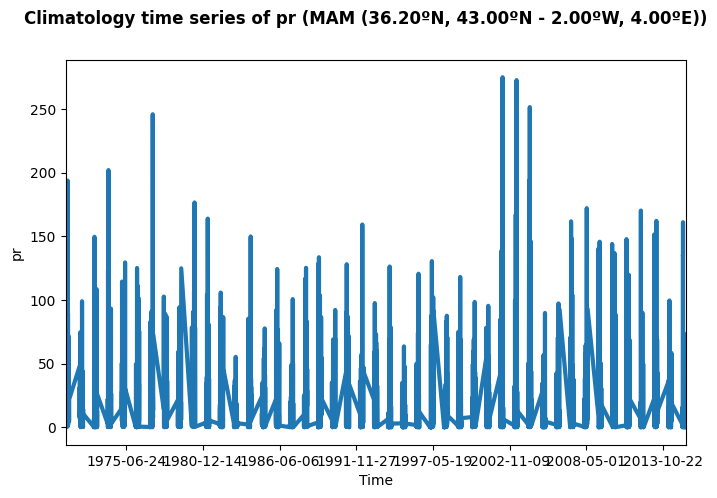

In [13]:
dsz = Dataset("Spain02_v5.0_DD_010reg_aa3d_pr.nc", folder=DATASETS_DIR).open().slice(Region(
    lat0=36.2, latf=43, lon0=-2, lonf=4,
    month0=Month.MAR, monthf=Month.MAY,
    year0=1971, yearf=2015,
))

z = Clim(dsz, "ts", group_season=False)
z.plot(figsize=(8, 5))

(<Figure size 1280x800 with 1 Axes>,
 <Axes: xlabel='number of clusters', ylabel='IC'>)

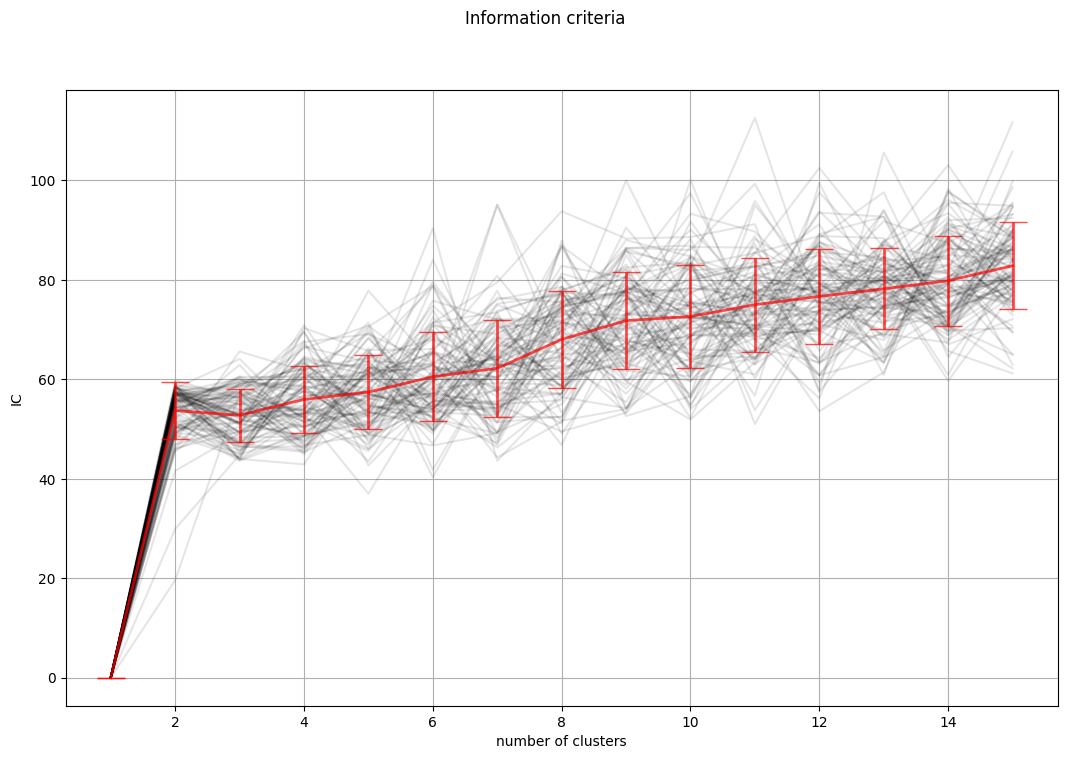

In [14]:
extremes = z.data.values > np.percentile(z.data.values, 95)
time_mask = ((pc.ds.time.dt.year >= dsz.region.year0) & (pc.ds.time.dt.year <= dsz.region.yearf)).values

pc.plot_IC(extremes=extremes, time_mask=time_mask)

### Una vez analizada la figura anterior, que es crucial, 
### decidimos el número de cluster a considerar


In [15]:
k = 4
wr = WeatherRegimes(pc=pc, k=k)
# wr.save("wr_", DATA_DIR)
# wr = WeatherRegimes.load("wr_", DATA_DIR, pc=pc)   

INFO 2026-06-30 19:26:47: Calculating Weather Regimes
  took 0.005 seconds


((<Figure size 800x800 with 1 Axes>,),
 ((<Axes3D: xlabel='PC1s', ylabel='PC2s', zlabel='PC3s'>,),))

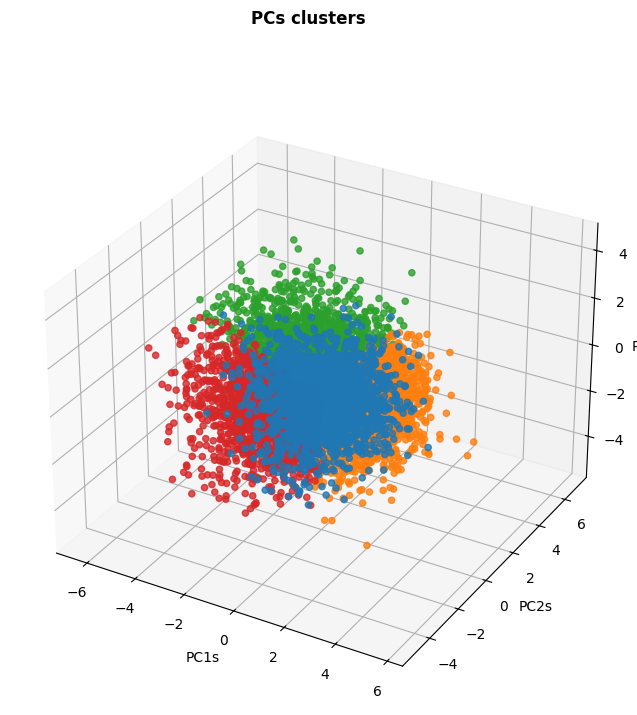

In [16]:
wr.plot_PCs()

## Cálculo de los mapas, como multiplicación de los centroides (coordenadas de PC1, PC2 y PC3) por los EOF (como mapa de regresión Reg)
#ES COMO UNA RECONSTRUCCIÓN
cluster=centroids*Reg
CENTROIDS 4, 10
REG     10, ns

((<Figure size 1436.36x800 with 5 Axes>,),
 ((<GeoAxes: title={'center': 'msl cluster 1. freq=25.8'}>,
   <GeoAxes: title={'center': 'msl cluster 2. freq=30.1'}>,
   <GeoAxes: title={'center': 'msl cluster 3. freq=22.6'}>,
   <GeoAxes: title={'center': 'msl cluster 4. freq=21.6'}>),))

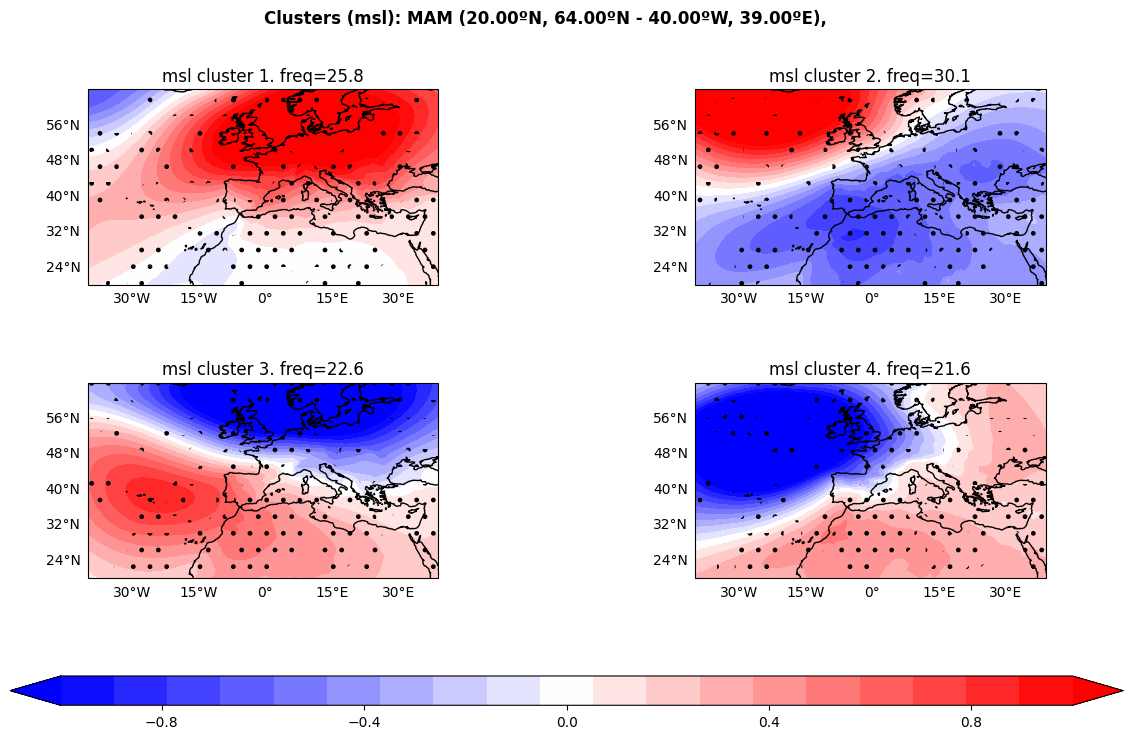

In [17]:
wr.plot()


# =============================================================================
# DIBUJAR CLUSTER i-ésimo (en realidad son las EOFs as reg)
# =============================================================================

## también podemos calcular el valor medio del índice para cada cluster 

### 1. Probabilidad de mi indice por encima de un percentil  en cada CLUSTER

In [18]:
prob_extreme = np.zeros(k, np.float32)

for i in range(k):
    prob_extreme[i] = np.sum((wr.index[time_mask] == i) & extremes)/np.sum(wr.index[time_mask] == i)

print("Probabilidad en toda la serie de extremo:", np.mean(extremes))
print("Probabilidad en cada cluster:", prob_extreme)

Probabilidad en toda la serie de extremo: 0.05
Probabilidad en cada cluster: [0.0534208  0.06568779 0.03677933 0.03622251]


### 2.  Total de mi indice para cada cluster


In [19]:
mean_per_cluster = np.zeros(k, np.float32)

for i in range(k):
    mean_per_cluster[i] = np.mean(z.data.values[wr.index[time_mask] == i])

print("Media en toda la serie:", np.mean(z.data.values))
print("Media en cada cluster:", mean_per_cluster)

Media en toda la serie: 16.306805
Media en cada cluster: [16.161432 21.000427 13.201921 12.691121]


###  3. frecuencia de que aparezca mi indice en cada  WR

In [20]:
prob_of_WR = np.zeros(k, np.float32)

for i in range(k):
    prob_of_WR[i] = np.mean(wr.index[time_mask] == i)

print("Probabilidad de cada cluster:", prob_of_WR)

Probabilidad de cada cluster: [0.25772947 0.31256038 0.24299517 0.18671498]


In [21]:
pre.data

array([[  41.794044, -216.52615 , -406.84634 , ...,  142.09894 ,
         154.34125 ,   47.77104 ],
       [  30.564938, -230.505   , -393.82495 , ...,  143.07918 ,
         156.57173 ,   61.75178 ],
       [  13.025574, -243.04416 , -392.6139  , ...,  146.18613 ,
         152.9289  ,   73.85915 ],
       ...,
       [ 199.6427  , 1182.0942  ,  671.79584 , ...,  321.0022  ,
         580.51624 ,  478.7178  ],
       [ 188.81943 , 1105.2705  ,  697.7217  , ...,  283.60736 ,
         611.121   ,  500.0721  ],
       [ 162.30292 , 1067.7534  ,  718.4538  , ...,  311.96375 ,
         650.9767  ,  520.1771  ]], shape=(3600, 7820), dtype=float32)

((<Figure size 1436.36x800 with 5 Axes>,),
 ((<GeoAxes: title={'center': 'msl cluster 1 COMPOSED. freq=25.8'}>,
   <GeoAxes: title={'center': 'msl cluster 2 COMPOSED. freq=30.1'}>,
   <GeoAxes: title={'center': 'msl cluster 3 COMPOSED. freq=22.6'}>,
   <GeoAxes: title={'center': 'msl cluster 4 COMPOSED. freq=21.6'}>),))

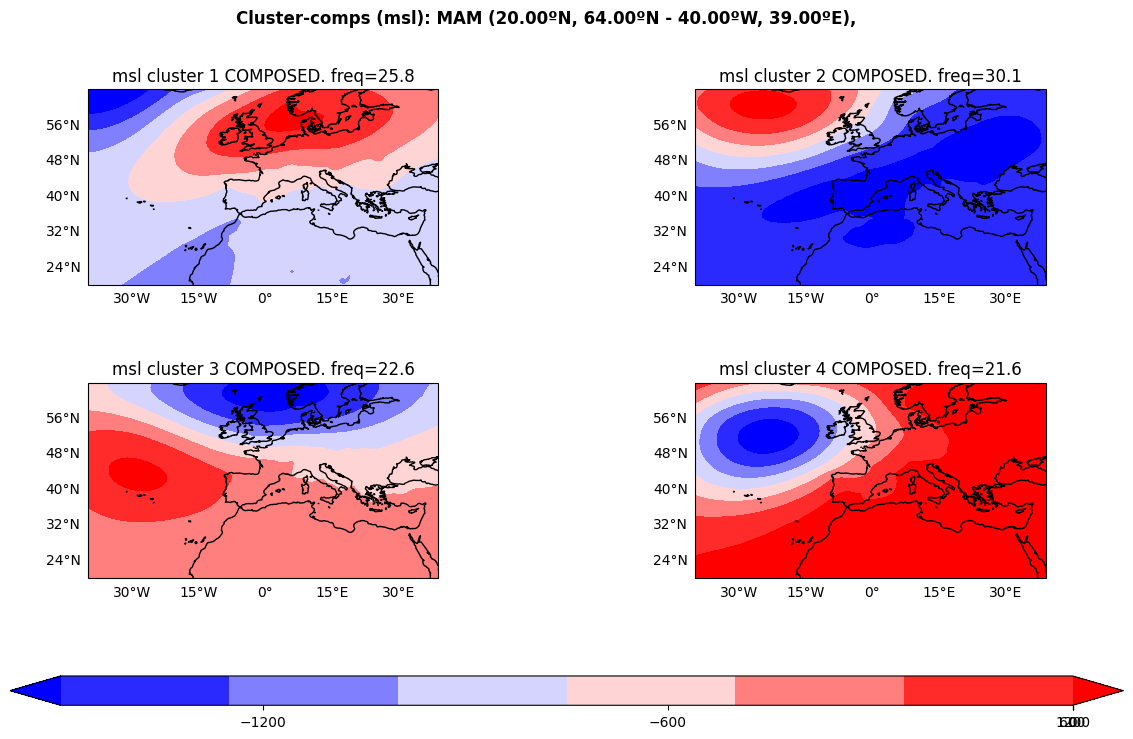

In [22]:
wr.plot(plot_composed=True)

In [23]:
## ahora, para cada año, vas viendo la frecuencia de tu cluster
nyr=84
dy = 92
wr1= np.empty([nyr,])
wr2= np.empty([nyr,])
wr3= np.empty([nyr,])
wr4= np.empty([nyr,])


k=0

# each year contains  ndy days
for i in range(nyr):
    wr1[i] = sum(wr.index[k:k+dy] == 0) #sumo todos los valores del índice
    wr2[i] = sum(wr.index[k:k+dy] == 1) 
    wr3[i] = sum(wr.index[k:k+dy] == 2)
    wr4[i] = sum(wr.index[k:k+dy] == 3)
   
    k=k+dy

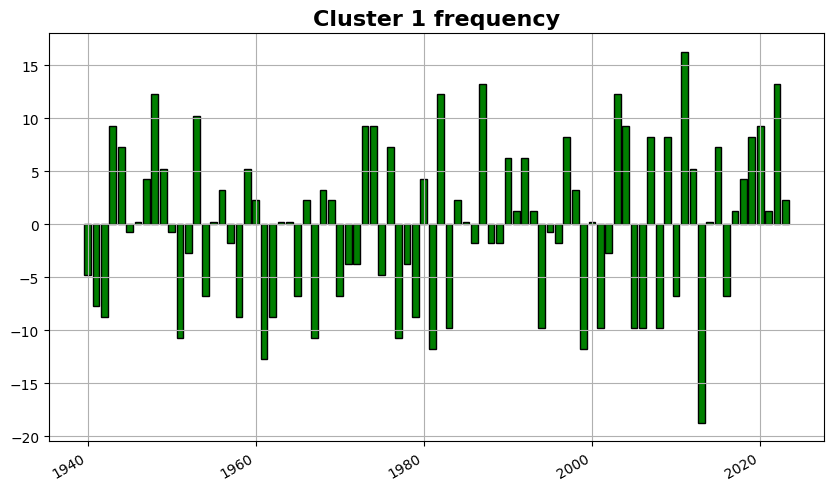

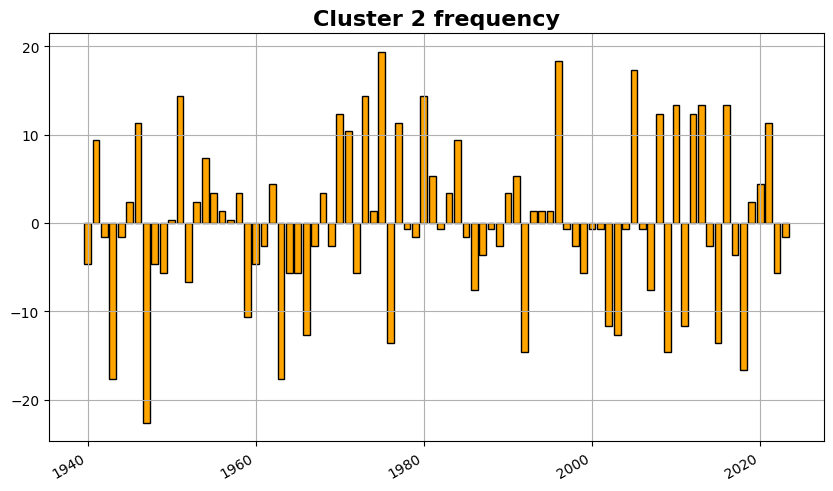

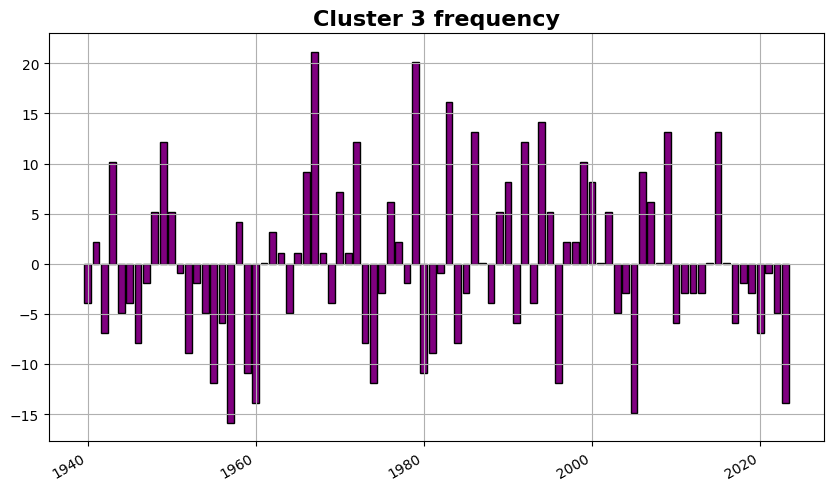

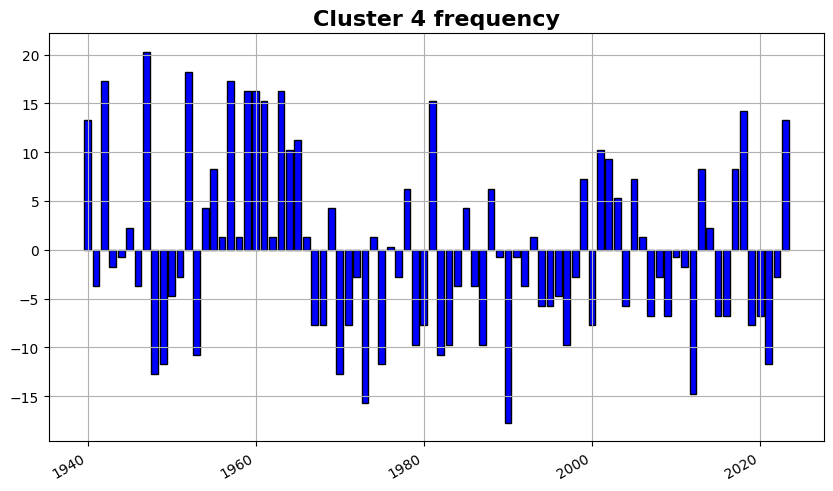

In [24]:

# Ploteamos las frecuencias
fig,ax = plt.subplots(1,1,figsize=(10,6))
fig.autofmt_xdate(rotation=30) 
ax.set_title('Cluster 1 frequency',fontsize=16,weight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.bar(np.arange(1940,2024),wr1-wr1.mean(),linewidth= 1,color='green', edgecolor = 'k')
ax.grid()

fig,ax = plt.subplots(1,1,figsize=(10,6))
fig.autofmt_xdate(rotation=30) 
ax.set_title('Cluster 2 frequency',fontsize=16,weight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.bar(np.arange(1940,2024),wr2-wr2.mean(),linewidth= 1,color='orange', edgecolor = 'k')
ax.grid()

fig,ax = plt.subplots(1,1,figsize=(10,6))
fig.autofmt_xdate(rotation=30) 
ax.set_title('Cluster 3 frequency',fontsize=16,weight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.bar(np.arange(1940,2024),wr3-wr3.mean(),linewidth= 1,color='purple', edgecolor = 'k')
ax.grid()

fig,ax = plt.subplots(1,1,figsize=(10,6))
fig.autofmt_xdate(rotation=30) 
ax.set_title('Cluster 4 frequency',fontsize=16,weight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.bar(np.arange(1940,2024),wr4-wr4.mean(),linewidth= 1,color='blue', edgecolor = 'k')
ax.grid()